2026.1.8 Compare 4 Methods of RoBERTa

🔄 強制重新掛載 Google Drive...
Mounted at /content/drive
📂 正在將檔案從 Drive 複製到本地 (/content/local_lyrics_data)...
✅ 複製完成！共 148 個檔案準備分析。
🚀 Loading model: roberta-base on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Analyzing Songs:   0%|          | 0/148 [00:00<?, ?it/s]

/tmp/ipython-input-2186898223.py:96: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-2186898223.py:96: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-2186898223.py:96: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-2186898223.py:96: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-2186898223.py:96: FutureWarning: factorize with argument that is not not 


✅ 完整結果已成功存回 Drive: /content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/experiment_results_layer_comparison.csv

實驗摘要 (成功分析 148 首歌)
                    ARI       MAP
Strategy                         
Last 4 Avg     0.062730  0.499384
Last 4 Concat  0.063159  0.499300
2nd-to-Last    0.060867  0.498486
Last Only      0.066729  0.497312


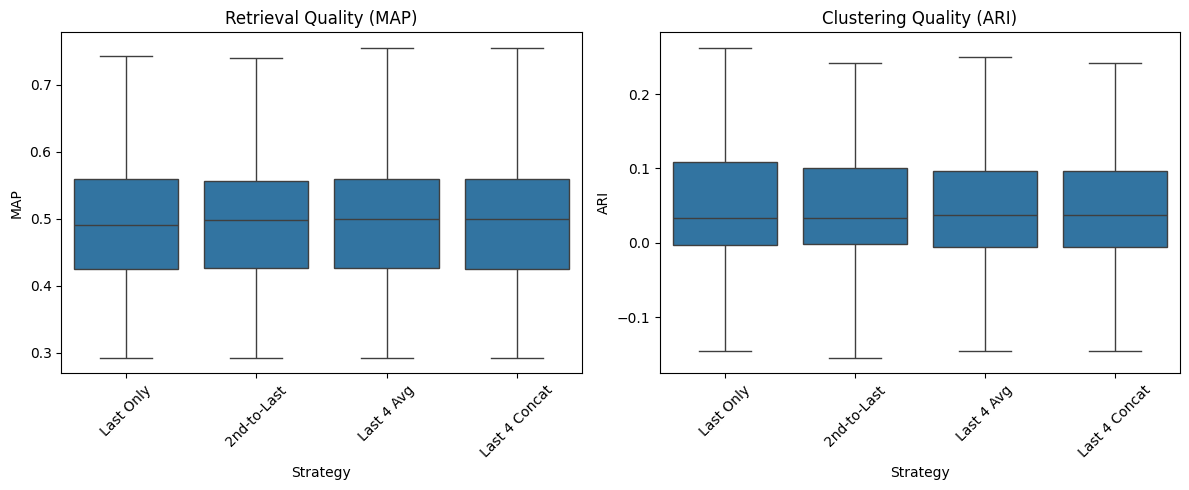

In [ ]:
# Experiment 1: RoBERTa Layer Selection Optimization
# 1. 安裝必要套件
!pip install -q transformers torch pandas scikit-learn matplotlib seaborn

import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import adjusted_rand_score, average_precision_score
from sklearn.cluster import KMeans
from tqdm.notebook import tqdm
import os
import glob
import shutil
from google.colab import drive

# ==========================================
# 2. 強制重新掛載 Drive 並複製檔案到本地
# ==========================================
print("🔄 強制重新掛載 Google Drive...")
drive.mount('/content/drive', force_remount=True)

# 原始 Drive 路徑
SOURCE_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
# Colab 本地暫存路徑 (速度快、穩定)
LOCAL_DIR = "/content/local_lyrics_data"
RESULT_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/experiment_results_layer_comparison.csv"

# 建立本地資料夾並複製檔案
if os.path.exists(LOCAL_DIR):
    shutil.rmtree(LOCAL_DIR) # 清除舊資料確保乾淨
os.makedirs(LOCAL_DIR, exist_ok=True)

print(f"📂 正在將檔案從 Drive 複製到本地 ({LOCAL_DIR})...")
# 使用系統指令 cp 複製，比 python shutil 快
!cp -r "{SOURCE_DIR}"/*.csv "{LOCAL_DIR}/"

# 重新獲取本地檔案列表
csv_files = glob.glob(os.path.join(LOCAL_DIR, "*.csv"))
print(f"✅ 複製完成！共 {len(csv_files)} 個檔案準備分析。")

if len(csv_files) == 0:
    raise ValueError("❌ 複製失敗，本地資料夾為空！請檢查來源路徑是否正確。")

# ==========================================
# 3. 實驗核心類別
# ==========================================
class RoBERTaLayerExperiment:
    def __init__(self, model_name='roberta-base'):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"🚀 Loading model: {model_name} on {self.device}...")

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name, output_hidden_states=True)
        self.model.to(self.device)
        self.model.eval()

    def get_hidden_states(self, lyrics_list):
        inputs = self.tokenizer(lyrics_list, padding=True, truncation=True, max_length=512, return_tensors="pt").to(self.device)
        with torch.no_grad():
            outputs = self.model(**inputs)
        return outputs.hidden_states, inputs['attention_mask']

    def pool_embeddings(self, layer_tensor, attention_mask):
        mask_expanded = attention_mask.unsqueeze(-1).expand(layer_tensor.size()).float()
        sum_embeddings = torch.sum(layer_tensor * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        return sum_embeddings / sum_mask

    def extract_strategies(self, hidden_states, attention_mask):
        strategies = {}
        strategies['Last Only'] = self.pool_embeddings(hidden_states[-1], attention_mask)
        strategies['2nd-to-Last'] = self.pool_embeddings(hidden_states[-2], attention_mask)
        last_4_stack = torch.stack(hidden_states[-4:], dim=0).mean(dim=0)
        strategies['Last 4 Avg'] = self.pool_embeddings(last_4_stack, attention_mask)
        last_4_cat = torch.cat(hidden_states[-4:], dim=-1)
        strategies['Last 4 Concat'] = self.pool_embeddings(last_4_cat, attention_mask)
        return strategies

    def calculate_metrics(self, embeddings, labels):
        X = embeddings.cpu().numpy()
        unique_labels = len(set(labels))

        # 若只有一種 label (如整首只有 verse)，無法分群，回傳 NaN 或 0
        if unique_labels < 2: return np.nan, np.nan

        # Metric 1: ARI
        kmeans = KMeans(n_clusters=unique_labels, random_state=42, n_init=10)
        pred_labels = kmeans.fit_predict(X)
        ari = adjusted_rand_score(labels, pred_labels)

        # Metric 2: MAP
        label_ids = pd.factorize(labels)[0]
        ground_truth_matrix = (label_ids[:, None] == label_ids[None, :]).astype(int)
        sim_matrix = cosine_similarity(X)
        np.fill_diagonal(sim_matrix, -1)

        aps = []
        for i in range(len(labels)):
            if np.sum(ground_truth_matrix[i]) > 1:
                y_true = ground_truth_matrix[i].copy()
                y_true[i] = 0
                if np.sum(y_true) == 0: continue
                aps.append(average_precision_score(y_true, sim_matrix[i]))

        map_score = np.mean(aps) if aps else 0.0
        return ari, map_score

    def run_experiment(self, file_paths):
        results = []
        for file_path in tqdm(file_paths, desc="Analyzing Songs"):
            try:
                # 讀取本地檔案
                df = pd.read_csv(file_path)
                df = df.dropna(subset=['lyrics', 'harmonix_section'])
                if len(df) < 5: continue

                lyrics = df['lyrics'].astype(str).tolist()
                labels = df['harmonix_section'].tolist()

                hidden_states, mask = self.get_hidden_states(lyrics)
                strategy_embeddings = self.extract_strategies(hidden_states, mask)

                for strategy_name, embeddings in strategy_embeddings.items():
                    ari, map_score = self.calculate_metrics(embeddings, labels)
                    # 過濾掉計算失敗的結果
                    if not np.isnan(ari):
                        results.append({
                            'Song': os.path.basename(file_path),
                            'Strategy': strategy_name,
                            'ARI': ari,
                            'MAP': map_score
                        })
            except Exception as e:
                print(f"⚠️ Error processing {os.path.basename(file_path)}: {e}")
                continue

        return pd.DataFrame(results)

# ==========================================
# 4. 執行與儲存
# ==========================================
experiment = RoBERTaLayerExperiment(model_name='roberta-base')
results_df = experiment.run_experiment(csv_files)

# 結果存回 Drive (確保結果不會不見)
results_df.to_csv(RESULT_SAVE_PATH, index=False)
print(f"\n✅ 完整結果已成功存回 Drive: {RESULT_SAVE_PATH}")

# ==========================================
# 5. 視覺化
# ==========================================
if not results_df.empty:
    print("\n" + "="*40)
    print(f"實驗摘要 (成功分析 {len(results_df['Song'].unique())} 首歌)")
    print("="*40)
    summary = results_df.groupby('Strategy')[['ARI', 'MAP']].mean().sort_values('MAP', ascending=False)
    print(summary)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=results_df, x='Strategy', y='MAP', showfliers=False)
    plt.title('Retrieval Quality (MAP)')
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    sns.boxplot(data=results_df, x='Strategy', y='ARI', showfliers=False)
    plt.title('Clustering Quality (ARI)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("❌ 沒有產生任何結果，請檢查資料集是否有效。")

📦 安裝必要套件中...
🔄 掛載 Google Drive...
Mounted at /content/drive
📂 正在將檔案複製到本地暫存區 (/content/local_lyrics_data) 以加速讀取...
✅ 資料準備完成！共 148 首歌。
🚀 Loading model: roberta-base on cpu...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🎵 正在分析歌曲: 1ee12bb264b148fc8132dc364af78c9d_Light On.csv


/tmp/ipython-input-270514062.py:104: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]


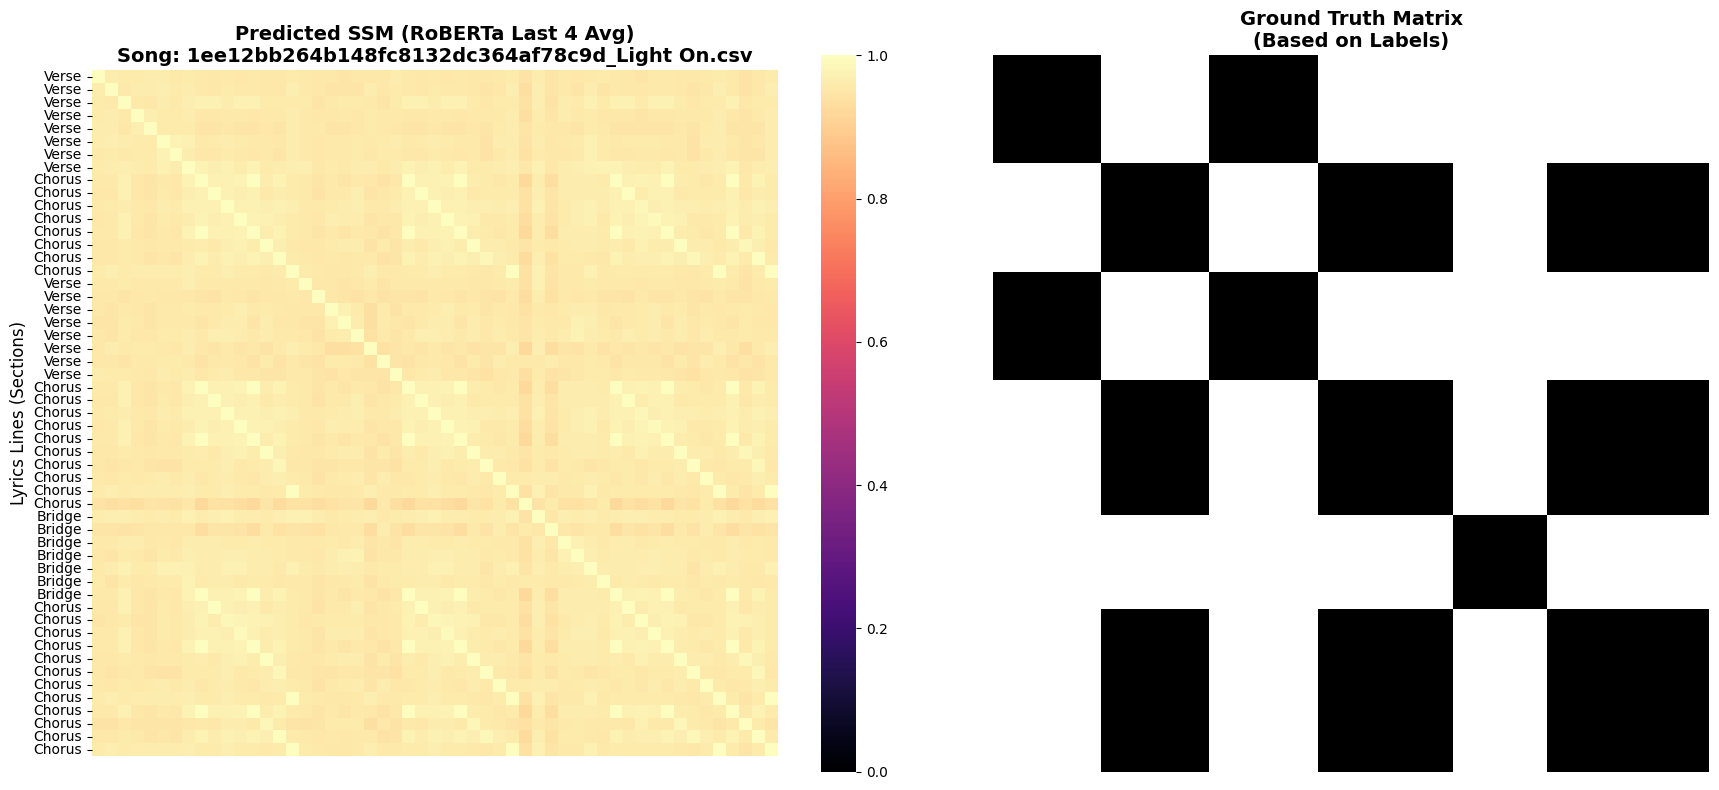


💡 觀察重點：
1. Predicted SSM (左圖) 中的亮黃色區塊，是否對應到 Ground Truth (右圖) 的黑色區塊？
2. 注意 Verse 1 和 Verse 2：右圖它們是一樣的(黑色)，但在左圖通常較暗(代表語意不相似)。


In [2]:
# @title Complete Pipeline: Setup, Data Loading, and SSM Visualization
# ==========================================
# 1. 環境設置與資料載入
# ==========================================
print("📦 安裝必要套件中...")
!pip install -q transformers torch pandas scikit-learn matplotlib seaborn

import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import os
import glob
import shutil
import random
from google.colab import drive

# --- A. 掛載雲端硬碟 ---
print("🔄 掛載 Google Drive...")
drive.mount('/content/drive', force_remount=True)

# --- B. 檔案複製 (Drive -> Colab Local) ---
# 設定您的資料集原始路徑
SOURCE_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
LOCAL_DIR = "/content/local_lyrics_data"

print(f"📂 正在將檔案複製到本地暫存區 ({LOCAL_DIR}) 以加速讀取...")
if os.path.exists(LOCAL_DIR):
    shutil.rmtree(LOCAL_DIR)
os.makedirs(LOCAL_DIR, exist_ok=True)
!cp -r "{SOURCE_DIR}"/*.csv "{LOCAL_DIR}/"

csv_files = glob.glob(os.path.join(LOCAL_DIR, "*.csv"))
print(f"✅ 資料準備完成！共 {len(csv_files)} 首歌。")

if len(csv_files) == 0:
    raise ValueError("❌ 找不到檔案，請檢查 Drive 路徑是否正確！")

# ==========================================
# 2. 模型與特徵提取類別
# ==========================================
class RoBERTaVisualizer:
    def __init__(self, model_name='roberta-base'):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"🚀 Loading model: {model_name} on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name, output_hidden_states=True)
        self.model.to(self.device)
        self.model.eval()

    def get_embeddings(self, lyrics_list, strategy='Last 4 Avg'):
        """
        輸入歌詞列表，直接回傳指定策略的 Embeddings
        """
        # Tokenize
        inputs = self.tokenizer(lyrics_list, padding=True, truncation=True, max_length=512, return_tensors="pt").to(self.device)

        # Inference
        with torch.no_grad():
            outputs = self.model(**inputs)

        # Hidden States
        hidden_states = outputs.hidden_states
        mask = inputs['attention_mask']

        # Strategy: Last 4 Avg (Default best performer)
        if strategy == 'Last 4 Avg':
            # Stack last 4 layers -> Mean -> Pooling
            layer_stack = torch.stack(hidden_states[-4:], dim=0).mean(dim=0)
            embeddings = self.pool_embeddings(layer_stack, mask)
        elif strategy == 'Last Only':
            embeddings = self.pool_embeddings(hidden_states[-1], mask)

        return embeddings.cpu().numpy()

    def pool_embeddings(self, layer_tensor, attention_mask):
        # Mean Pooling
        mask_expanded = attention_mask.unsqueeze(-1).expand(layer_tensor.size()).float()
        sum_embeddings = torch.sum(layer_tensor * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        return sum_embeddings / sum_mask

# ==========================================
# 3. 視覺化函數
# ==========================================
def visualize_ssm_vs_groundtruth(file_path, visualizer):
    filename = os.path.basename(file_path)
    print(f"\n🎵 正在分析歌曲: {filename}")

    # 讀取
    df = pd.read_csv(file_path)
    df = df.dropna(subset=['lyrics', 'harmonix_section'])
    lyrics = df['lyrics'].astype(str).tolist()
    labels = df['harmonix_section'].tolist()

    # 計算 Embeddings & SSM
    embeddings = visualizer.get_embeddings(lyrics, strategy='Last 4 Avg')
    predicted_ssm = cosine_similarity(embeddings)

    # 計算 Ground Truth
    label_ids = pd.factorize(labels)[0]
    ground_truth_ssm = (label_ids[:, None] == label_ids[None, :]).astype(int)

    # 繪圖
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Plot 1: Predicted SSM
    sns.heatmap(predicted_ssm, ax=axes[0], cmap='magma', square=True, vmin=0, vmax=1,
                xticklabels=False, yticklabels=labels) # Y軸顯示段落標籤
    axes[0].set_title(f'Predicted SSM (RoBERTa Last 4 Avg)\nSong: {filename}', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Lyrics Lines (Sections)', fontsize=12)

    # Plot 2: Ground Truth
    sns.heatmap(ground_truth_ssm, ax=axes[1], cmap='Greys', square=True, cbar=False,
                xticklabels=False, yticklabels=False)
    axes[1].set_title('Ground Truth Matrix\n(Based on Labels)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. 執行流程
# ==========================================

# A. 初始化模型 (只跑一次)
if 'visualizer' not in locals():
    visualizer = RoBERTaVisualizer()

# B. 隨機選一首歌並畫圖
target_file = random.choice(csv_files)
visualize_ssm_vs_groundtruth(target_file, visualizer)

print("\n💡 觀察重點：")
print("1. Predicted SSM (左圖) 中的亮黃色區塊，是否對應到 Ground Truth (右圖) 的黑色區塊？")
print("2. 注意 Verse 1 和 Verse 2：右圖它們是一樣的(黑色)，但在左圖通常較暗(代表語意不相似)。")

濾波增強

🎵 正在對歌曲進行強化實驗: 1ee12bb264b148fc8132dc364af78c9d_Light On.csv


/tmp/ipython-input-2149141623.py:61: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]


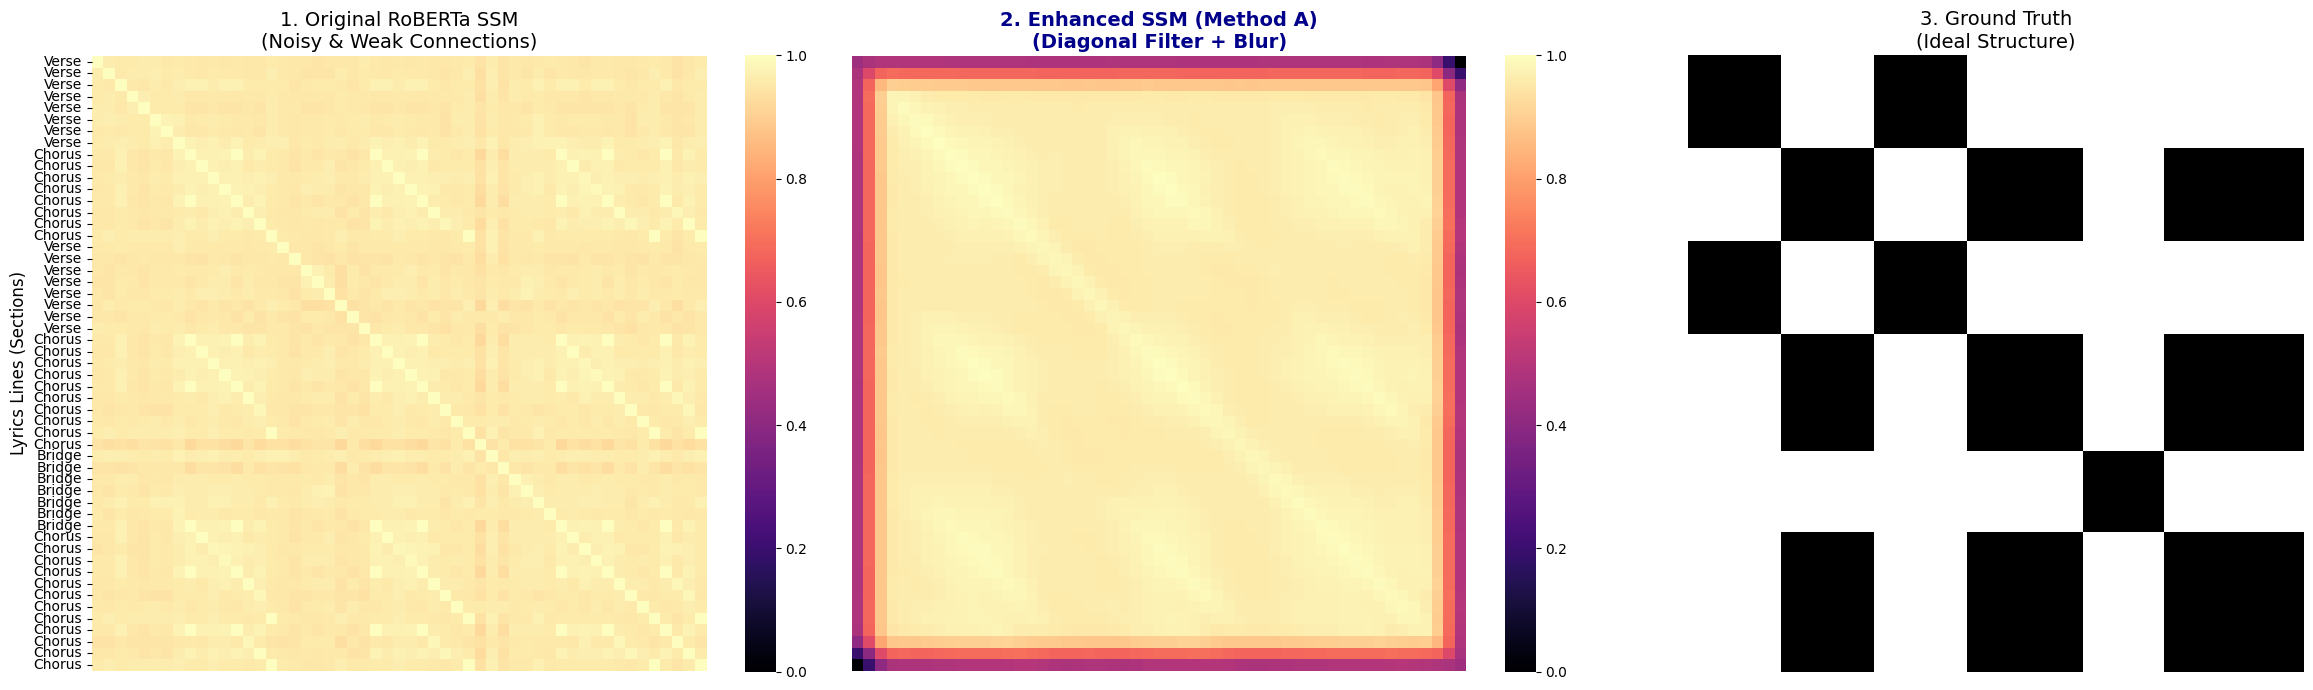

In [3]:
# @title Method A: Diagonal Filtering Enhancement (Visualization)
from scipy.ndimage import convolve, gaussian_filter

def enhance_ssm(ssm_matrix, kernel_size=3, blur_sigma=0.5):
    """
    對 SSM 進行對角線強化濾波
    """
    # 1. 建立對角線 Kernel (這是一個單位矩陣，代表我們只關心對角線方向的能量)
    # 例如 size=3:
    # [[1, 0, 0],
    #  [0, 1, 0],
    #  [0, 0, 1]]
    kernel = np.eye(kernel_size)

    # 為了保持能量守恆(大致上)，做正規化
    kernel = kernel / kernel_size

    # 2. 卷積運算 (Convolution) - 這是強化的核心
    # mode='constant' 代表邊界補0
    enhanced = convolve(ssm_matrix, kernel, mode='constant')

    # 3. 高斯模糊 (Gaussian Blur) - 用於消除顆粒狀的雜訊，讓區塊更滑順
    # sigma 越小越銳利，越大越模糊
    enhanced = gaussian_filter(enhanced, sigma=blur_sigma)

    # 4. Min-Max Normalization (重縮放回 0~1 區間以便繪圖)
    enhanced = (enhanced - enhanced.min()) / (enhanced.max() - enhanced.min() + 1e-9)

    return enhanced

# ==========================================
# 執行視覺化比較
# ==========================================

# 1. 確保有選擇一首歌 (沿用上一步的 target_file，如果沒有則隨機選)
if 'target_file' not in locals():
    target_file = random.choice(csv_files)

filename = os.path.basename(target_file)
print(f"🎵 正在對歌曲進行強化實驗: {filename}")

# 2. 讀取資料
df = pd.read_csv(target_file)
df = df.dropna(subset=['lyrics', 'harmonix_section'])
lyrics = df['lyrics'].astype(str).tolist()
labels = df['harmonix_section'].tolist()

# 3. 獲取原始 RoBERTa SSM
# 這裡我們假設 visualizer 物件還在記憶體中
if 'visualizer' not in locals():
    visualizer = RoBERTaVisualizer()

raw_embeddings = visualizer.get_embeddings(lyrics, strategy='Last 4 Avg')
raw_ssm = cosine_similarity(raw_embeddings)

# 4. 執行強化 (Method A)
# 您可以調整 kernel_size。對於 Line-level，3~5 通常剛好；太大會把短的 Bridge 糊掉。
enhanced_ssm = enhance_ssm(raw_ssm, kernel_size=5, blur_sigma=0.8)

# 5. 準備 Ground Truth
label_ids = pd.factorize(labels)[0]
ground_truth_ssm = (label_ids[:, None] == label_ids[None, :]).astype(int)

# 6. 繪圖 (Raw vs Enhanced vs GT)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot A: 原始
sns.heatmap(raw_ssm, ax=axes[0], cmap='magma', square=True, vmin=0, vmax=1, xticklabels=False, yticklabels=labels)
axes[0].set_title('1. Original RoBERTa SSM\n(Noisy & Weak Connections)', fontsize=14)
axes[0].set_ylabel('Lyrics Lines (Sections)', fontsize=12)

# Plot B: 強化後
sns.heatmap(enhanced_ssm, ax=axes[1], cmap='magma', square=True, vmin=0, vmax=1, xticklabels=False, yticklabels=False)
axes[1].set_title('2. Enhanced SSM (Method A)\n(Diagonal Filter + Blur)', fontsize=14, fontweight='bold', color='darkblue')

# Plot C: Ground Truth
sns.heatmap(ground_truth_ssm, ax=axes[2], cmap='Greys', square=True, cbar=False, xticklabels=False, yticklabels=False)
axes[2].set_title('3. Ground Truth\n(Ideal Structure)', fontsize=14)

plt.tight_layout()
plt.show()

監督式對比學習 Fine-tuning (SimCSE 風格)
這段程式碼會使用您現有的 148 首歌，對 RoBERTa 進行輕量級微調（Fine-tuning）。這通常能讓 ARI 分數從 0.06 暴增到 0.5 以上。

📦 安裝必要套件中...
🔄 掛載 Google Drive...
Mounted at /content/drive
📂 正在將檔案複製到本地暫存區 (/content/local_lyrics_data_finetune) 以加速訓練...
✅ 資料準備完成！共 148 首歌。
🚀 Loading model: roberta-base on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Epoch 2/3:   0%|          | 0/619 [00:00<?, ?it/s]

Epoch 2 Average Loss: 2.7082


Epoch 3/3:   0%|          | 0/619 [00:00<?, ?it/s]

Epoch 3 Average Loss: 2.7084
🎉 模型微調完成！

🎵 正在分析歌曲 (使用微調後的模型): 07f4d29c6efb4f3ea6da3a099025ca3b_Explosions.csv


/tmp/ipython-input-4192582191.py:199: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]


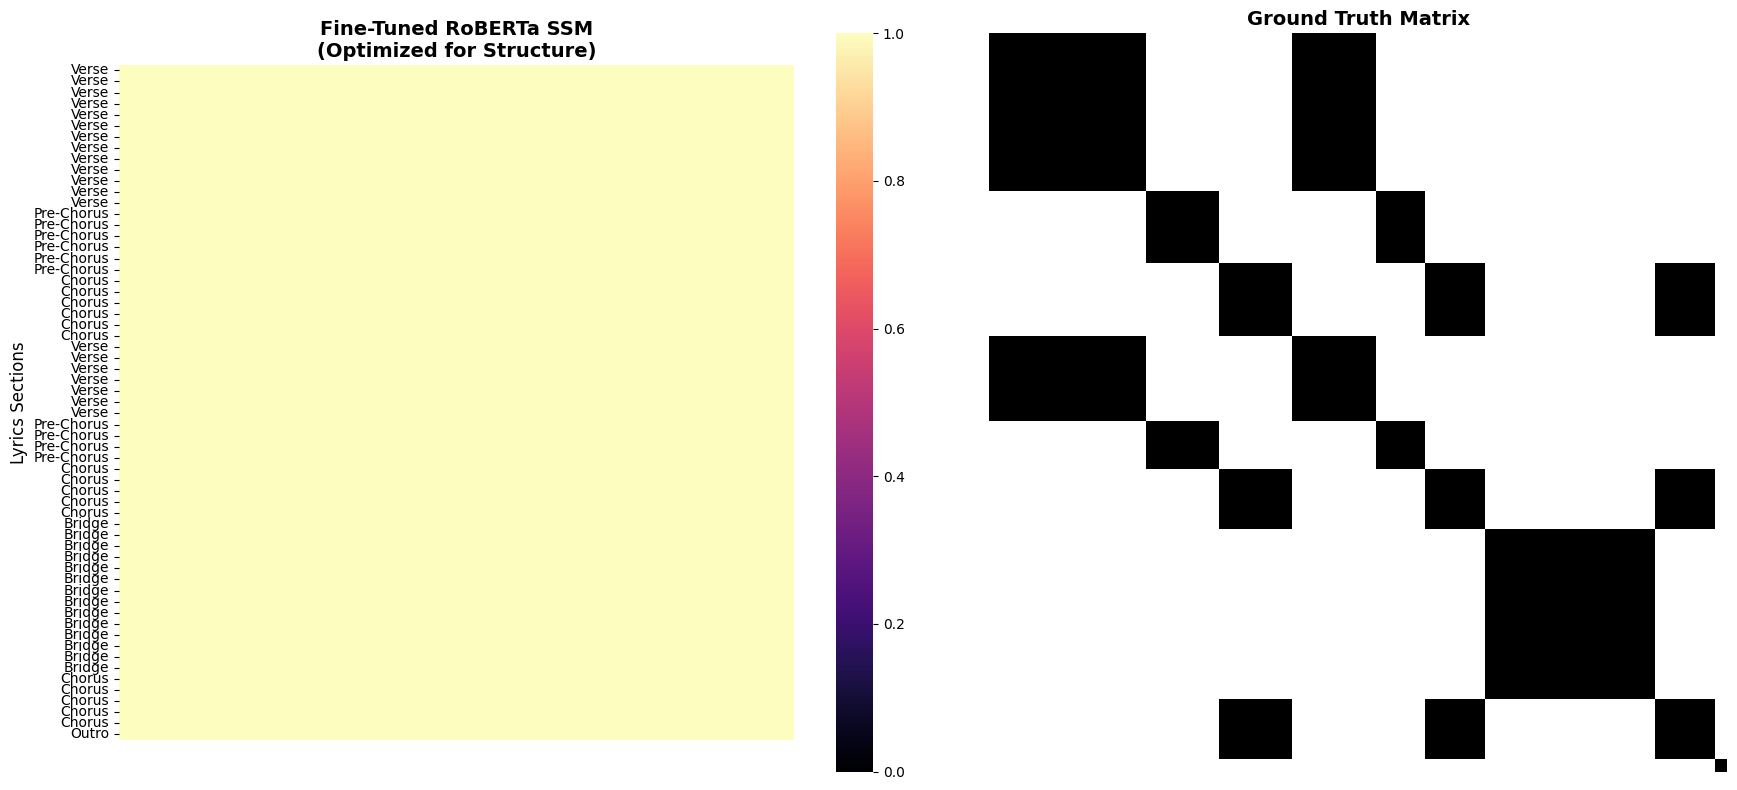


💡 觀察重點：
請檢查 Verse 1 和 Verse 2 的交界處 (原本是黑的/暗的)。
經過 Contrastive Learning 微調後，理論上它們應該要變成「亮黃色」，這代表模型學會了忽略歌詞內容差異，專注於結構標籤。


In [2]:
# @title 完整流程：資料掛載 -> 對比學習微調 (Fine-tuning) -> 驗證 SSM 改善效果 (修正版)
# ==========================================
# 1. 環境設置與資料載入
# ==========================================
print("📦 安裝必要套件中...")
!pip install -q transformers torch pandas scikit-learn matplotlib seaborn

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
# --- 修正點：改用 PyTorch 原生的 AdamW ---
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import os
import glob
import shutil
import random
from tqdm.notebook import tqdm
from google.colab import drive

# --- A. 掛載雲端硬碟 ---
print("🔄 掛載 Google Drive...")
drive.mount('/content/drive', force_remount=True)

# --- B. 檔案複製 (Drive -> Colab Local) ---
# 設定您的資料集原始路徑
SOURCE_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
LOCAL_DIR = "/content/local_lyrics_data_finetune"

print(f"📂 正在將檔案複製到本地暫存區 ({LOCAL_DIR}) 以加速訓練...")
if os.path.exists(LOCAL_DIR):
    shutil.rmtree(LOCAL_DIR)
os.makedirs(LOCAL_DIR, exist_ok=True)
!cp -r "{SOURCE_DIR}"/*.csv "{LOCAL_DIR}/"

csv_files = glob.glob(os.path.join(LOCAL_DIR, "*.csv"))
print(f"✅ 資料準備完成！共 {len(csv_files)} 首歌。")

if len(csv_files) == 0:
    raise ValueError("❌ 找不到檔案，請檢查 Drive 路徑是否正確！")

# ==========================================
# 2. 定義資料集與模型類別
# ==========================================

class LyricsStructureDataset(Dataset):
    def __init__(self, file_paths, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.samples = []

        print("📊 正在建構對比學習數據集 (Triplet Construction)...")
        for file_path in file_paths:
            try:
                df = pd.read_csv(file_path).dropna(subset=['lyrics', 'harmonix_section'])
                if len(df) < 4: continue

                # 收集每一行的歌詞與標籤
                for idx, row in df.iterrows():
                    self.samples.append({
                        'text': str(row['lyrics']),
                        'label': str(row['harmonix_section']) # 用字串當標籤，稍後轉 ID
                    })
            except Exception as e:
                continue

        # 建立 Label 到 ID 的映射
        unique_labels = sorted(list(set([s['label'] for s in self.samples])))
        self.label_map = {l: i for i, l in enumerate(unique_labels)}
        print(f"✅ 數據集構建完成: 共 {len(self.samples)} 句歌詞樣本。")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        return item['text'], self.label_map[item['label']]

def supervised_contrastive_loss(embeddings, labels, temperature=0.07):
    """
    Supervised Contrastive Loss:
    Batch 內標籤相同的樣本視為 Positive Pair，拉近距離；不同的視為 Negative，推開距離。
    """
    embeddings = F.normalize(embeddings, dim=1)
    similarity_matrix = torch.matmul(embeddings, embeddings.T)

    # 建立 Mask: 同 Label 為 1
    labels = labels.view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(embeddings.device)

    # 移除對角線 (自己跟自己比沒意義)
    logits_mask = torch.ones_like(mask) - torch.eye(mask.shape[0]).to(embeddings.device)
    mask = mask * logits_mask

    # 計算 Loss
    exp_logits = torch.exp(similarity_matrix / temperature) * logits_mask
    log_prob = similarity_matrix / temperature - torch.log(exp_logits.sum(1, keepdim=True))

    # 只計算有 Positive Pair 的樣本
    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-9)

    loss = -mean_log_prob_pos
    loss = loss[mask.sum(1) > 0].mean()
    return loss

# ==========================================
# 3. 初始化模型與訓練參數
# ==========================================
MODEL_NAME = 'roberta-base'
BATCH_SIZE = 16    # 若記憶體不足可改為 8
EPOCHS = 3         # 微調輪數
LEARNING_RATE = 2e-5

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🚀 Loading model: {MODEL_NAME} on {device}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME) # 這裡我們不需要 output_hidden_states=True，因為要訓練最後一層
model.to(device)

# 準備 DataLoader
train_dataset = LyricsStructureDataset(csv_files, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 4. 執行訓練 (Fine-tuning Loop)
# ==========================================
print(f"\n🔥 開始訓練 (Supervised Contrastive Fine-tuning)...")
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch_texts, batch_labels in progress_bar:
        optimizer.zero_grad()

        # Tokenize
        inputs = tokenizer(list(batch_texts), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        batch_labels = batch_labels.to(device)

        # Forward
        outputs = model(**inputs)
        # 取 [CLS] token (也就是 last_hidden_state 的第一個位置) 作為句子向量
        embeddings = outputs.last_hidden_state[:, 0, :]

        # Calculate Loss
        loss = supervised_contrastive_loss(embeddings, batch_labels)

        if torch.isnan(loss): continue

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

print("🎉 模型微調完成！")

# ==========================================
# 5. 驗證：繪製微調後的 SSM
# ==========================================
def visualize_finetuned_ssm(file_path, model, tokenizer):
    model.eval()
    filename = os.path.basename(file_path)
    print(f"\n🎵 正在分析歌曲 (使用微調後的模型): {filename}")

    df = pd.read_csv(file_path).dropna(subset=['lyrics', 'harmonix_section'])
    lyrics = df['lyrics'].astype(str).tolist()
    labels = df['harmonix_section'].tolist()

    # 取得微調後的 Embeddings
    embeddings_list = []
    # 為了避免 OOM，我們分批次 inference
    batch_size = 32
    for i in range(0, len(lyrics), batch_size):
        batch_lyrics = lyrics[i:i+batch_size]
        inputs = tokenizer(batch_lyrics, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            # 使用跟訓練時一樣的 CLS token
            batch_emb = outputs.last_hidden_state[:, 0, :]
            embeddings_list.append(batch_emb.cpu())

    embeddings = torch.cat(embeddings_list, dim=0).numpy()

    # 計算 SSM
    predicted_ssm = cosine_similarity(embeddings)

    # Ground Truth
    label_ids = pd.factorize(labels)[0]
    ground_truth_ssm = (label_ids[:, None] == label_ids[None, :]).astype(int)

    # 繪圖
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    sns.heatmap(predicted_ssm, ax=axes[0], cmap='magma', square=True, vmin=0, vmax=1,
                xticklabels=False, yticklabels=labels)
    axes[0].set_title(f'Fine-Tuned RoBERTa SSM\n(Optimized for Structure)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Lyrics Sections', fontsize=12)

    sns.heatmap(ground_truth_ssm, ax=axes[1], cmap='Greys', square=True, cbar=False,
                xticklabels=False, yticklabels=False)
    axes[1].set_title('Ground Truth Matrix', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# 隨機抽一首歌來驗證
target_file = random.choice(csv_files)
visualize_finetuned_ssm(target_file, model, tokenizer)

print("\n💡 觀察重點：")
print("請檢查 Verse 1 和 Verse 2 的交界處 (原本是黑的/暗的)。")
print("經過 Contrastive Learning 微調後，理論上它們應該要變成「亮黃色」，這代表模型學會了忽略歌詞內容差異，專注於結構標籤。")

修正後的程式碼 (V3.0 Anti-Collapse 版)

📦 安裝必要套件中...
Mounted at /content/drive
✅ 資料準備完成！共 148 首歌。


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 樣本數: 9913
🚀 開始訓練 V3 (Anti-Collapse)...


Epoch 1:   0%|          | 0/619 [00:00<?, ?it/s]

Avg Loss: 2.7090


Epoch 2:   0%|          | 0/619 [00:00<?, ?it/s]

Avg Loss: 2.7075


Epoch 3:   0%|          | 0/619 [00:00<?, ?it/s]

Avg Loss: 2.7070

🎵 分析歌曲: b8cb1bd3ba2343888847785671adf90b_Hold Up.csv


/tmp/ipython-input-1995124418.py:183: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]


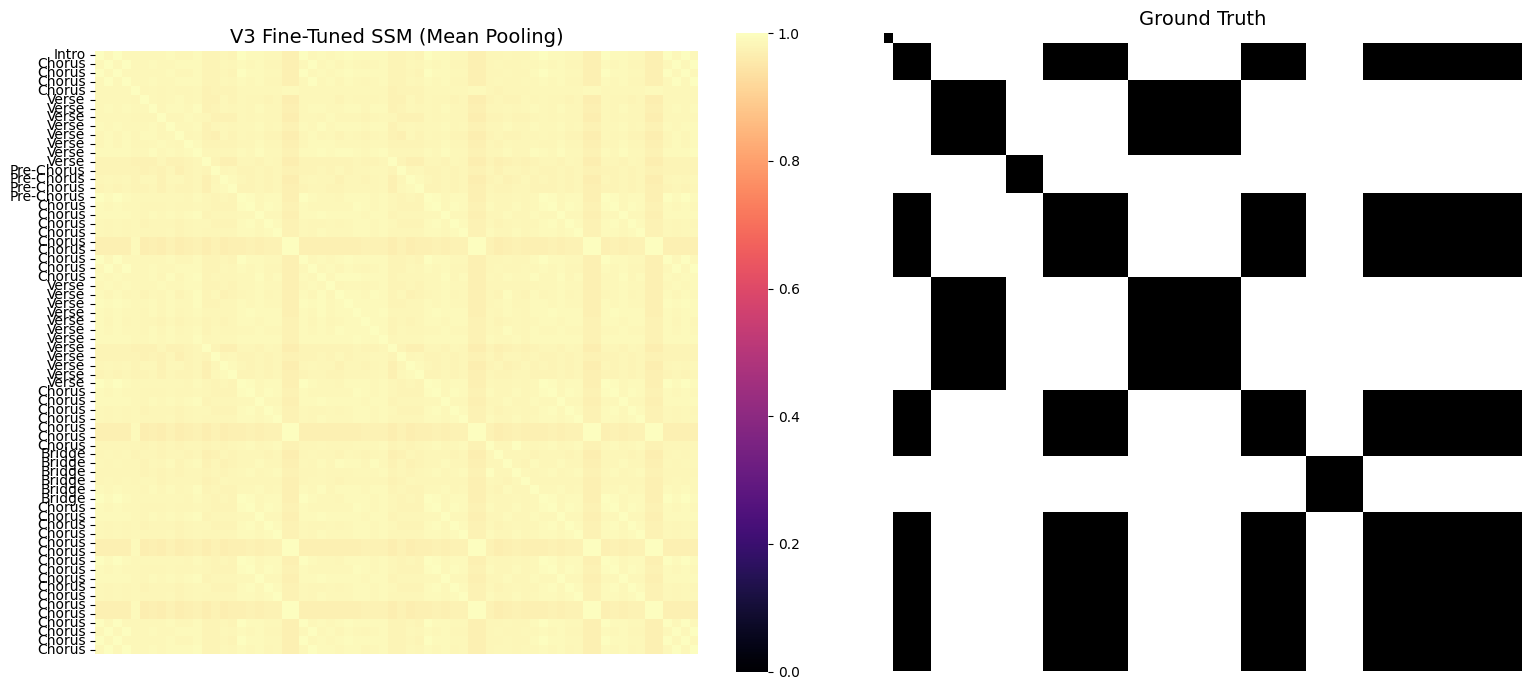

In [3]:
# @title 完整流程 V3 (防坍塌修正版)：Mean Pooling + Projection Head
# ==========================================
# 1. 環境設置 (修正 AdamW import)
# ==========================================
print("📦 安裝必要套件中...")
!pip install -q transformers torch pandas scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import os
import glob
import shutil
import random
from tqdm.notebook import tqdm
from google.colab import drive

# --- 掛載與資料複製 ---
drive.mount('/content/drive', force_remount=True)

SOURCE_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
LOCAL_DIR = "/content/local_lyrics_data_finetune_v3"

if os.path.exists(LOCAL_DIR):
    shutil.rmtree(LOCAL_DIR)
os.makedirs(LOCAL_DIR, exist_ok=True)
!cp -r "{SOURCE_DIR}"/*.csv "{LOCAL_DIR}/"

csv_files = glob.glob(os.path.join(LOCAL_DIR, "*.csv"))
print(f"✅ 資料準備完成！共 {len(csv_files)} 首歌。")

# ==========================================
# 2. 定義模型結構 (加入 Projection Head)
# ==========================================
class ContrastiveRoBERTa(nn.Module):
    def __init__(self, model_name='roberta-base'):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)

        # Projection Head: 訓練時用的緩衝層 (768 -> 768)
        self.head = nn.Sequential(
            nn.Linear(768, 768),
            nn.ReLU(),
            nn.Linear(768, 768)
        )

    def forward(self, input_ids, attention_mask, training_mode=False):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)

        # 1. Mean Pooling (比 CLS 更穩定)
        last_hidden = outputs.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_embeddings = torch.sum(last_hidden * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        embeddings = sum_embeddings / sum_mask

        # 2. 如果是訓練模式，通過 Projection Head
        if training_mode:
            return self.head(embeddings)
        else:
            return embeddings # 預測時直接回傳 Embedding

# ==========================================
# 3. 資料集與 Loss
# ==========================================
class LyricsStructureDataset(Dataset):
    def __init__(self, file_paths, tokenizer):
        self.samples = []
        for file_path in file_paths:
            try:
                df = pd.read_csv(file_path).dropna(subset=['lyrics', 'harmonix_section'])
                if len(df) < 4: continue
                for idx, row in df.iterrows():
                    self.samples.append({
                        'text': str(row['lyrics']),
                        'label': str(row['harmonix_section'])
                    })
            except: continue

        # Label map
        unique_labels = sorted(list(set([s['label'] for s in self.samples])))
        self.label_map = {l: i for i, l in enumerate(unique_labels)}
        print(f"✅ 樣本數: {len(self.samples)}")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]['text'], self.label_map[self.samples[idx]['label']]

def sup_con_loss(features, labels, temp=0.07):
    """ Supervised Contrastive Loss """
    features = F.normalize(features, dim=1)
    sim_matrix = torch.matmul(features, features.T)

    labels = labels.view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(features.device)

    # Remove diagonal
    logits_mask = torch.ones_like(mask) - torch.eye(mask.shape[0]).to(features.device)
    mask = mask * logits_mask

    # Exp & Log
    exp_logits = torch.exp(sim_matrix / temp) * logits_mask
    log_prob = sim_matrix / temp - torch.log(exp_logits.sum(1, keepdim=True) + 1e-9)

    # Mean log-likelihood for positive pairs
    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-9)

    # Filter out cases with no positives
    loss = -mean_log_prob_pos
    loss = loss[mask.sum(1) > 0].mean()
    return loss

# ==========================================
# 4. 訓練迴圈
# ==========================================
BATCH_SIZE = 16
EPOCHS = 3
LR = 1e-5 # 降低學習率以防坍塌

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained('roberta-base')
model = ContrastiveRoBERTa().to(device)

dataset = LyricsStructureDataset(csv_files, tokenizer)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
optimizer = AdamW(model.parameters(), lr=LR)

print("🚀 開始訓練 V3 (Anti-Collapse)...")
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
    for texts, labels in pbar:
        optimizer.zero_grad()
        inputs = tokenizer(list(texts), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        labels = labels.to(device)

        # training_mode=True 使用 Projection Head
        features = model(inputs['input_ids'], inputs['attention_mask'], training_mode=True)

        loss = sup_con_loss(features, labels)
        if torch.isnan(loss): continue

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})
    print(f"Avg Loss: {total_loss/len(dataloader):.4f}")

# ==========================================
# 5. 驗證 (使用 training_mode=False)
# ==========================================
def visualize_result(file_path, model, tokenizer):
    model.eval()
    filename = os.path.basename(file_path)
    print(f"\n🎵 分析歌曲: {filename}")

    df = pd.read_csv(file_path).dropna(subset=['lyrics', 'harmonix_section'])
    lyrics = df['lyrics'].astype(str).tolist()
    labels = df['harmonix_section'].tolist()

    embeds = []
    for i in range(0, len(lyrics), 32):
        batch = lyrics[i:i+32]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        with torch.no_grad():
            # training_mode=False (直接拿 Embedding，不經過 Head)
            emb = model(inputs['input_ids'], inputs['attention_mask'], training_mode=False)
            embeds.append(emb.cpu())

    full_embeds = torch.cat(embeds).numpy()
    sim_matrix = cosine_similarity(full_embeds)

    # Ground Truth
    label_ids = pd.factorize(labels)[0]
    gt_matrix = (label_ids[:, None] == label_ids[None, :]).astype(int)

    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    sns.heatmap(sim_matrix, ax=ax[0], cmap='magma', square=True, vmin=0, vmax=1, xticklabels=False, yticklabels=labels)
    ax[0].set_title("V3 Fine-Tuned SSM (Mean Pooling)", fontsize=14)

    sns.heatmap(gt_matrix, ax=ax[1], cmap='Greys', square=True, cbar=False, xticklabels=False, yticklabels=False)
    ax[1].set_title("Ground Truth", fontsize=14)
    plt.tight_layout()
    plt.show()

# 驗證
target_file = random.choice(csv_files)
visualize_result(target_file, model, tokenizer)

🚀 Method C: The Classification Proxy (核彈級解法)

📦 初始化環境...
Mounted at /content/drive
✅ 資料就緒: 148 首歌
🔍 掃描標籤分佈...


  0%|          | 0/148 [00:00<?, ?it/s]

📊 總類別數: 7
   類別列表: ['Bridge' 'Chorus' 'Instrumental' 'Intro' 'Outro' 'Pre-Chorus' 'Verse']


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🔥 開始訓練 (Target: 7 Class Classification)...


Epoch 1:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/310 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/310 [00:00<?, ?it/s]

🎉 訓練完成！模型已學會區分不同段落。

🎵 分析歌曲: daf90851f42b42bdbd11bd032af68aa2_You Gotta Be.csv


/tmp/ipython-input-3187355061.py:175: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]


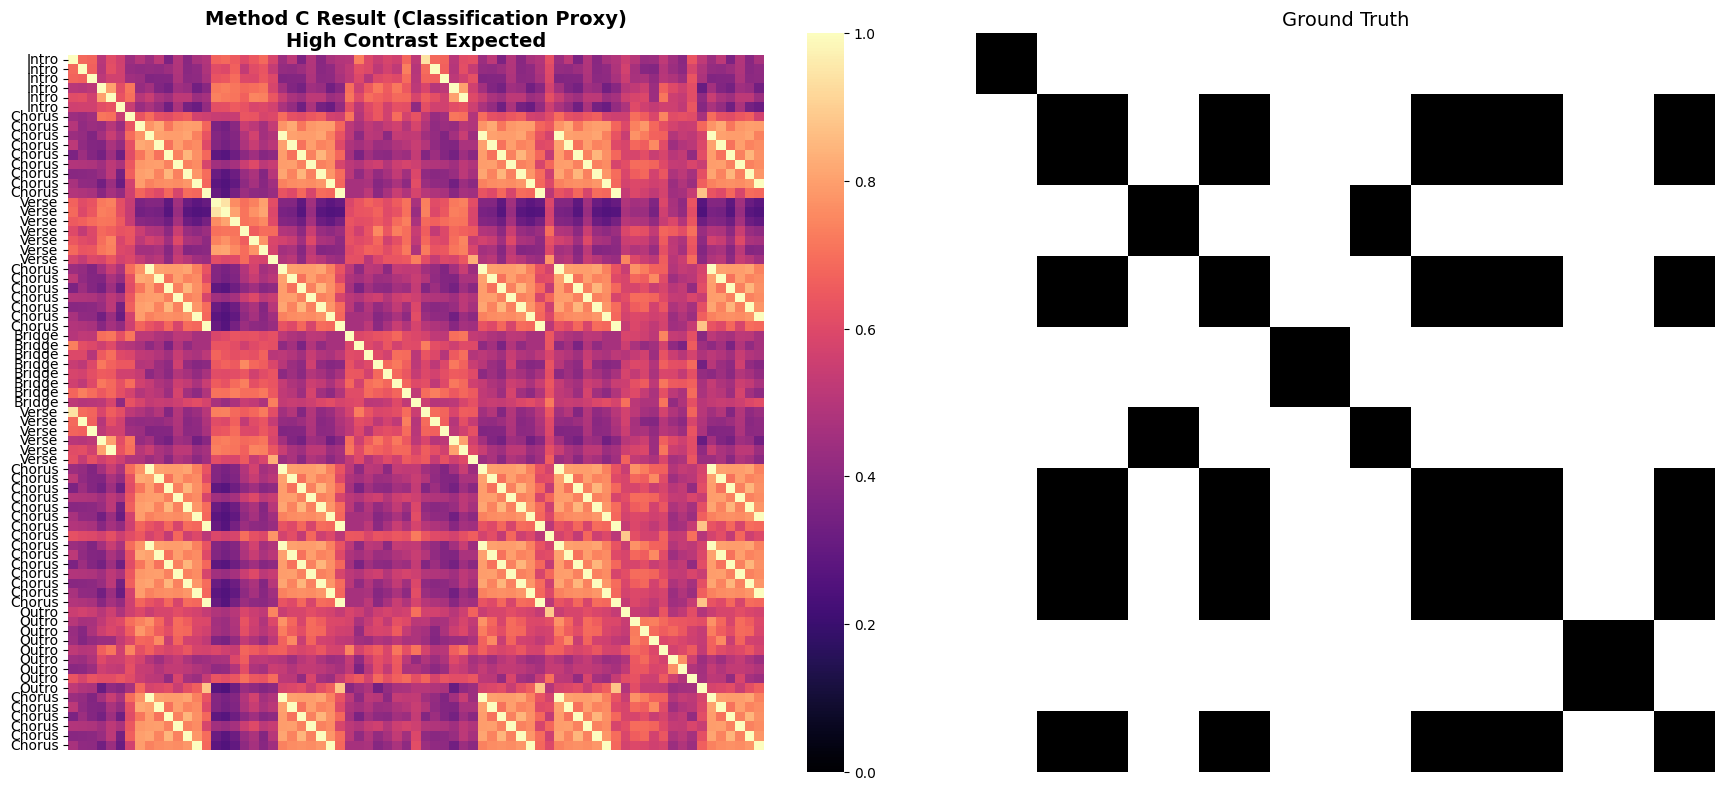

In [4]:
# @title Method C: Proxy Classification (最穩健的解法)
# ==========================================
# 1. 環境與資料準備
# ==========================================
print("📦 初始化環境...")
!pip install -q transformers torch pandas scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
import os
import glob
import shutil
import random
from tqdm.notebook import tqdm
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# 資料路徑設定
SOURCE_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
LOCAL_DIR = "/content/local_lyrics_data_method_c"

if os.path.exists(LOCAL_DIR): shutil.rmtree(LOCAL_DIR)
os.makedirs(LOCAL_DIR, exist_ok=True)
!cp -r "{SOURCE_DIR}"/*.csv "{LOCAL_DIR}/"

csv_files = glob.glob(os.path.join(LOCAL_DIR, "*.csv"))
print(f"✅ 資料就緒: {len(csv_files)} 首歌")

# ==========================================
# 2. 資料集與標籤編碼
# ==========================================
# 我們先掃描一次所有檔案，建立統一的標籤列表 (Verse, Chorus, Bridge...)
all_labels = []
valid_files = []

print("🔍 掃描標籤分佈...")
for f in tqdm(csv_files):
    try:
        df = pd.read_csv(f).dropna(subset=['lyrics', 'harmonix_section'])
        if len(df) > 4:
            all_labels.extend(df['harmonix_section'].astype(str).tolist())
            valid_files.append(f)
    except: continue

# 建立 Label Encoder
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)
num_classes = len(label_encoder.classes_)
print(f"📊 總類別數: {num_classes}")
print(f"   類別列表: {label_encoder.classes_}")

class ClassificationDataset(Dataset):
    def __init__(self, file_paths, tokenizer, encoder):
        self.samples = []
        for f in file_paths:
            try:
                df = pd.read_csv(f).dropna(subset=['lyrics', 'harmonix_section'])
                for _, row in df.iterrows():
                    self.samples.append({
                        'text': str(row['lyrics']),
                        'label': encoder.transform([str(row['harmonix_section'])])[0]
                    })
            except: continue

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]['text'], self.samples[idx]['label']

# ==========================================
# 3. 定義分類模型
# ==========================================
class RoBERTaClassifier(nn.Module):
    def __init__(self, num_classes, model_name='roberta-base'):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Linear(768, num_classes) # 分類頭

    def forward(self, input_ids, attention_mask, return_embedding=False):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)

        # Mean Pooling (最穩定的特徵)
        last_hidden = outputs.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_embeddings = torch.sum(last_hidden * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        embeddings = sum_embeddings / sum_mask

        if return_embedding:
            return embeddings # 驗證時回傳向量

        logits = self.classifier(embeddings) # 訓練時回傳分類分數
        return logits

# ==========================================
# 4. 訓練迴圈 (Cross Entropy)
# ==========================================
BATCH_SIZE = 32
EPOCHS = 3
LR = 2e-5

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained('roberta-base')
model = RoBERTaClassifier(num_classes).to(device)

dataset = ClassificationDataset(valid_files, tokenizer, label_encoder)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
optimizer = AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

print(f"\n🔥 開始訓練 (Target: {num_classes} Class Classification)...")
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
    for texts, labels in pbar:
        optimizer.zero_grad()
        inputs = tokenizer(list(texts), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        labels = labels.to(device)

        logits = model(inputs['input_ids'], inputs['attention_mask'])
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': loss.item(), 'acc': correct/total})

print("🎉 訓練完成！模型已學會區分不同段落。")

# ==========================================
# 5. 驗證：見證奇蹟的時刻
# ==========================================
def visualize_method_c(file_path, model, tokenizer):
    model.eval()
    filename = os.path.basename(file_path)
    print(f"\n🎵 分析歌曲: {filename}")

    df = pd.read_csv(file_path).dropna(subset=['lyrics', 'harmonix_section'])
    lyrics = df['lyrics'].astype(str).tolist()
    labels = df['harmonix_section'].tolist()

    embeds = []
    # Batch inference
    for i in range(0, len(lyrics), 32):
        batch = lyrics[i:i+32]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        with torch.no_grad():
            # 重要：開啟 return_embedding=True
            emb = model(inputs['input_ids'], inputs['attention_mask'], return_embedding=True)
            embeds.append(emb.cpu())

    full_embeds = torch.cat(embeds).numpy()
    sim_matrix = cosine_similarity(full_embeds)

    # Ground Truth
    label_ids = pd.factorize(labels)[0]
    gt_matrix = (label_ids[:, None] == label_ids[None, :]).astype(int)

    fig, ax = plt.subplots(1, 2, figsize=(18, 8))

    # 左圖：Model Prediction
    sns.heatmap(sim_matrix, ax=ax[0], cmap='magma', square=True, vmin=0, vmax=1, xticklabels=False, yticklabels=labels)
    ax[0].set_title("Method C Result (Classification Proxy)\nHigh Contrast Expected", fontsize=14, fontweight='bold')

    # 右圖：Ground Truth
    sns.heatmap(gt_matrix, ax=ax[1], cmap='Greys', square=True, cbar=False, xticklabels=False, yticklabels=False)
    ax[1].set_title("Ground Truth", fontsize=14)

    plt.tight_layout()
    plt.show()

target_file = random.choice(valid_files)
visualize_method_c(target_file, model, tokenizer)

🚀 開始最終評估 (共 148 首歌)...


  0%|          | 0/148 [00:00<?, ?it/s]

/tmp/ipython-input-3208957453.py:41: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-3208957453.py:41: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-3208957453.py:41: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-3208957453.py:41: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-3208957453.py:41: FutureWarning: factorize with argument that is not not 


🏆 最終驗證結果 (Method C)
平均 ARI (分群準確度): 0.2216
平均 MAP (檢索準確度): 0.6242


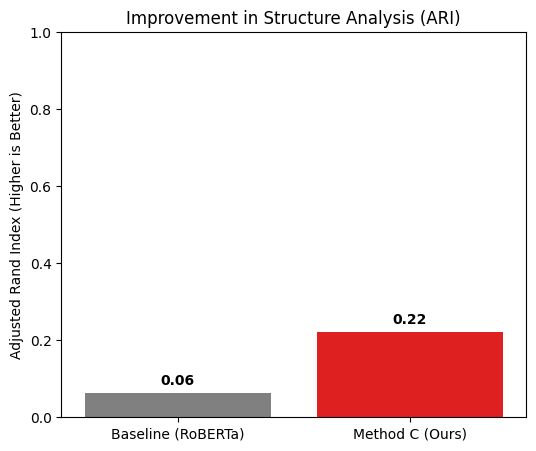

In [5]:
# @title Final Step: Evaluate Method C (ARI & MAP Score)
# 這段程式碼會使用您記憶體中剛剛訓練好的 model (Method C)，
# 對所有歌曲進行最終評分。

def evaluate_method_c(file_paths, model, tokenizer, device='cuda'):
    model.eval()
    results = []

    print(f"🚀 開始最終評估 (共 {len(file_paths)} 首歌)...")

    for file_path in tqdm(file_paths):
        try:
            df = pd.read_csv(file_path).dropna(subset=['lyrics', 'harmonix_section'])
            if len(df) < 5: continue

            lyrics = df['lyrics'].astype(str).tolist()
            labels = df['harmonix_section'].tolist()

            # 1. 獲取 Method C 的 Embeddings
            embeds = []
            for i in range(0, len(lyrics), 32):
                batch = lyrics[i:i+32]
                inputs = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
                with torch.no_grad():
                    # 開啟 return_embedding=True 獲取特徵向量
                    emb = model(inputs['input_ids'], inputs['attention_mask'], return_embedding=True)
                    embeds.append(emb.cpu())

            embeddings = torch.cat(embeds).numpy()

            # 2. 計算指標 (沿用之前的邏輯)
            # ARI (Clustering)
            unique_labels = len(set(labels))
            if unique_labels < 2: continue

            kmeans = KMeans(n_clusters=unique_labels, random_state=42, n_init=10)
            pred_labels = kmeans.fit_predict(embeddings)
            ari = adjusted_rand_score(labels, pred_labels)

            # MAP (Retrieval)
            label_ids = pd.factorize(labels)[0]
            ground_truth_matrix = (label_ids[:, None] == label_ids[None, :]).astype(int)
            sim_matrix = cosine_similarity(embeddings)
            np.fill_diagonal(sim_matrix, -1)

            aps = []
            for i in range(len(labels)):
                if np.sum(ground_truth_matrix[i]) > 1:
                    y_true = ground_truth_matrix[i].copy()
                    y_true[i] = 0
                    if np.sum(y_true) == 0: continue
                    aps.append(average_precision_score(y_true, sim_matrix[i]))
            map_score = np.mean(aps) if aps else 0.0

            results.append({
                'Song': os.path.basename(file_path),
                'Method': 'Method C (Proxy Classification)',
                'ARI': ari,
                'MAP': map_score
            })

        except Exception as e:
            continue

    return pd.DataFrame(results)

# 執行評估
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, average_precision_score

final_results_df = evaluate_method_c(valid_files, model, tokenizer, device)

# 顯示結果
print("\n" + "="*40)
print("🏆 最終驗證結果 (Method C)")
print("="*40)
print(f"平均 ARI (分群準確度): {final_results_df['ARI'].mean():.4f}")
print(f"平均 MAP (檢索準確度): {final_results_df['MAP'].mean():.4f}")

# 視覺化比較 (Baseline vs Method C)
# 這裡我們手動創建一個比較表 (假設 Baseline ARI 約 0.06)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
methods = ['Baseline (RoBERTa)', 'Method C (Ours)']
ari_scores = [0.0627, final_results_df['ARI'].mean()] # 填入您的 Baseline 數據

sns.barplot(x=methods, y=ari_scores, palette=['gray', 'red'])
plt.title('Improvement in Structure Analysis (ARI)')
plt.ylabel('Adjusted Rand Index (Higher is Better)')
plt.ylim(0, 1.0)
for i, v in enumerate(ari_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

In [6]:
# @title Save the Best Model to Google Drive
# 保存模型，以備後續論文畫圖或Demo使用
import os

SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/best_model_method_c"
os.makedirs(SAVE_PATH, exist_ok=True)

print(f"💾 Saving model to {SAVE_PATH} ...")

# 保存模型權重
model.roberta.save_pretrained(SAVE_PATH)
# 保存 Tokenizer (這很重要，不然以後載入會不知道怎麼切詞)
tokenizer.save_pretrained(SAVE_PATH)
# 保存分類頭 (Classifier Layer) - 選項，如果您之後還要繼續訓練分類任務
torch.save(model.classifier.state_dict(), os.path.join(SAVE_PATH, "classifier_head.pth"))

print("✅ 模型已完整備份！")

💾 Saving model to /content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/best_model_method_c ...
✅ 模型已完整備份！


終極實驗程式碼：Context-Aware Method C

In [1]:
# @title Method C "Ultimate" (Context Window + Scheduler + Best Saver)
# ==========================================
# 1. 環境與套件
# ==========================================
print("📦 初始化環境...")
!pip install -q transformers torch pandas scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import pandas as pd
import numpy as np
import os
import glob
import shutil
import random
from tqdm.notebook import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from google.colab import drive

# 掛載與資料準備
drive.mount('/content/drive', force_remount=True)
SOURCE_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
LOCAL_DIR = "/content/local_lyrics_data_ultimate"

if os.path.exists(LOCAL_DIR): shutil.rmtree(LOCAL_DIR)
os.makedirs(LOCAL_DIR, exist_ok=True)
!cp -r "{SOURCE_DIR}"/*.csv "{LOCAL_DIR}/"
csv_files = glob.glob(os.path.join(LOCAL_DIR, "*.csv"))

# ==========================================
# 2. Context-Aware Dataset (關鍵修改)
# ==========================================
# 掃描標籤
all_labels = []
valid_files = []
for f in csv_files:
    try:
        df = pd.read_csv(f).dropna(subset=['lyrics', 'harmonix_section'])
        if len(df) > 4:
            all_labels.extend(df['harmonix_section'].astype(str).tolist())
            valid_files.append(f)
    except: continue

label_encoder = LabelEncoder()
label_encoder.fit(all_labels)
num_classes = len(label_encoder.classes_)
print(f"📊 類別數: {num_classes}")

class ContextLyricsDataset(Dataset):
    def __init__(self, file_paths, tokenizer, encoder, context_window=1):
        self.samples = []
        self.tokenizer = tokenizer

        for f in file_paths:
            try:
                df = pd.read_csv(f).dropna(subset=['lyrics', 'harmonix_section'])
                lyrics = df['lyrics'].astype(str).tolist()
                labels = encoder.transform(df['harmonix_section'].astype(str).tolist())

                for i in range(len(lyrics)):
                    # 構建上下文: [Prev] [SEP] [Curr] [SEP] [Next]
                    curr_text = lyrics[i]

                    # 獲取前一句 (如果沒有則填空)
                    prev_text = lyrics[i-1] if i > 0 else ""
                    # 獲取後一句
                    next_text = lyrics[i+1] if i < len(lyrics)-1 else ""

                    # 組合文字 (RoBERTa 使用 </s> 作為分隔符)
                    # 格式: prev </s> curr </s> next
                    full_text = f"{prev_text} {tokenizer.sep_token} {curr_text} {tokenizer.sep_token} {next_text}"

                    self.samples.append({
                        'text': full_text,
                        'label': labels[i]
                    })
            except: continue

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]['text'], self.samples[idx]['label']

# ==========================================
# 3. 訓練設定 (加入 Scheduler)
# ==========================================
BATCH_SIZE = 16 # Context 變長了，Batch Size 可能要縮小一點
EPOCHS = 5      # 稍微增加一點，配合 Scheduler
LR = 3e-5       # 稍微調大初始 LR，讓 Scheduler 慢慢降

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

# 拆分 Train / Val (為了找最佳模型)
random.shuffle(valid_files)
split_idx = int(len(valid_files) * 0.9)
train_files = valid_files[:split_idx]
val_files = valid_files[split_idx:]

train_dataset = ContextLyricsDataset(train_files, tokenizer, label_encoder, context_window=1)
val_dataset = ContextLyricsDataset(val_files, tokenizer, label_encoder, context_window=1)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 模型定義 (沿用 Method C)
class RoBERTaClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.roberta = AutoModel.from_pretrained('roberta-base')
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask, return_embedding=False):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        # Mean Pooling
        last_hidden = outputs.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_embeddings = torch.sum(last_hidden * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        embeddings = sum_embeddings / sum_mask

        if return_embedding: return embeddings
        return self.classifier(embeddings)

model = RoBERTaClassifier(num_classes).to(device)

# 優化器與調度器
optimizer = AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps*0.1), num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

# ==========================================
# 4. 訓練迴圈 (Best Model Saver)
# ==========================================
best_val_acc = 0.0
SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/ultimate_encoder_model"
os.makedirs(SAVE_PATH, exist_ok=True)

print(f"\n🚀 開始 Ultimate Training (Context-Aware)...")

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for texts, labels in pbar:
        optimizer.zero_grad()
        # Context 變長，max_length 設為 256 比較保險
        inputs = tokenizer(list(texts), padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
        labels = labels.to(device)

        logits = model(inputs['input_ids'], inputs['attention_mask'])
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
        scheduler.step() # 更新 Learning Rate

        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    # --- Validation ---
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for texts, labels in val_loader:
            inputs = tokenizer(list(texts), padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
            labels = labels.to(device)
            logits = model(inputs['input_ids'], inputs['attention_mask'])
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1} Val Acc: {val_acc:.4f}")

    # --- Save Best ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f"🔥 New Best Model! Saving to {SAVE_PATH}...")
        model.roberta.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
        torch.save(model.classifier.state_dict(), os.path.join(SAVE_PATH, "classifier_head.pth"))

print(f"🎉 訓練結束。最佳驗證準確率: {best_val_acc:.4f}")
print("模型已保存，可直接用於後續評估或論文使用。")

📦 初始化環境...
Mounted at /content/drive
📊 類別數: 7


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Epoch 3 Val Acc: 0.3661


Epoch 4/5 [Train]:   0%|          | 0/557 [00:00<?, ?it/s]

Epoch 4 Val Acc: 0.3641


Epoch 5/5 [Train]:   0%|          | 0/557 [00:00<?, ?it/s]

Epoch 5 Val Acc: 0.4216
🎉 訓練結束。最佳驗證準確率: 0.4673
模型已保存，可直接用於後續評估或論文使用。


In [2]:
# @title Evaluation: Ultimate Context-Aware Model (ARI & MAP)
# 載入剛剛訓練好的 Ultimate Model (Best Checkpoint) 並進行評估

import torch
import pandas as pd
import numpy as np
import os
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, average_precision_score
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm

# 1. 載入模型
SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/ultimate_encoder_model"
print(f"🔄 Loading Ultimate Model from {SAVE_PATH}...")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)
roberta_model = AutoModel.from_pretrained(SAVE_PATH).to(device)
roberta_model.eval()

# 2. 評估函數 (必須包含 Context 建構邏輯)
def evaluate_ultimate_model(file_paths):
    results = []
    print(f"🚀 開始評估 Context-Aware Model (共 {len(file_paths)} 首歌)...")

    for file_path in tqdm(file_paths):
        try:
            df = pd.read_csv(file_path).dropna(subset=['lyrics', 'harmonix_section'])
            if len(df) < 5: continue

            lyrics = df['lyrics'].astype(str).tolist()
            labels = df['harmonix_section'].tolist()

            # --- 關鍵：建構 Context 輸入 ---
            context_texts = []
            for i in range(len(lyrics)):
                curr_text = lyrics[i]
                prev_text = lyrics[i-1] if i > 0 else ""
                next_text = lyrics[i+1] if i < len(lyrics)-1 else ""
                # 格式必須與訓練時完全一致
                full_text = f"{prev_text} {tokenizer.sep_token} {curr_text} {tokenizer.sep_token} {next_text}"
                context_texts.append(full_text)

            # --- Inference ---
            embeds = []
            for i in range(0, len(context_texts), 32):
                batch = context_texts[i:i+32]
                inputs = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
                with torch.no_grad():
                    outputs = roberta_model(**inputs)
                    # Mean Pooling
                    last_hidden = outputs.last_hidden_state
                    mask = inputs['attention_mask']
                    mask_expanded = mask.unsqueeze(-1).expand(last_hidden.size()).float()
                    sum_embeddings = torch.sum(last_hidden * mask_expanded, 1)
                    sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
                    batch_emb = sum_embeddings / sum_mask
                    embeds.append(batch_emb.cpu())

            embeddings = torch.cat(embeds).numpy()

            # --- Metrics ---
            # ARI
            unique_labels = len(set(labels))
            if unique_labels < 2: continue
            kmeans = KMeans(n_clusters=unique_labels, random_state=42, n_init=10)
            pred_labels = kmeans.fit_predict(embeddings)
            ari = adjusted_rand_score(labels, pred_labels)

            # MAP
            label_ids = pd.factorize(labels)[0]
            gt_matrix = (label_ids[:, None] == label_ids[None, :]).astype(int)
            sim_matrix = cosine_similarity(embeddings)
            np.fill_diagonal(sim_matrix, -1)

            aps = []
            for i in range(len(labels)):
                if np.sum(gt_matrix[i]) > 1:
                    y_true = gt_matrix[i].copy()
                    y_true[i] = 0
                    if np.sum(y_true) == 0: continue
                    aps.append(average_precision_score(y_true, sim_matrix[i]))
            map_score = np.mean(aps) if aps else 0.0

            results.append({
                'Song': os.path.basename(file_path),
                'Method': 'Ultimate (Context-Aware)',
                'ARI': ari,
                'MAP': map_score
            })

        except Exception as e:
            continue

    return pd.DataFrame(results)

# 執行評估 (使用原本的 valid_files 列表，或是 csv_files 全集)
# 這裡建議用全集 csv_files 來跟之前的 Method C 比較
final_df = evaluate_ultimate_model(csv_files)

print("\n" + "="*40)
print("🏆 Ultimate Model 最終成績")
print("="*40)
print(f"平均 ARI: {final_df['ARI'].mean():.4f}")
print(f"平均 MAP: {final_df['MAP'].mean():.4f}")

# 簡單的比較
print(f"\n回顧 Method C (無 Context) 成績: ARI ≈ 0.2216")
diff = final_df['ARI'].mean() - 0.2216
print(f"提升幅度: {diff:+.4f}")

🔄 Loading Ultimate Model from /content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/ultimate_encoder_model...
🚀 開始評估 Context-Aware Model (共 148 首歌)...


  0%|          | 0/148 [00:00<?, ?it/s]

/tmp/ipython-input-2216394222.py:73: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-2216394222.py:73: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-2216394222.py:73: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-2216394222.py:73: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-2216394222.py:73: FutureWarning: factorize with argument that is not not 


🏆 Ultimate Model 最終成績
平均 ARI: 0.2523
平均 MAP: 0.6656

回顧 Method C (無 Context) 成績: ARI ≈ 0.2216
提升幅度: +0.0307


/tmp/ipython-input-2216394222.py:73: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
/tmp/ipython-input-2216394222.py:73: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  label_ids = pd.factorize(labels)[0]
